<a href="https://colab.research.google.com/github/Sandrajol/NLP_Tarea_04/blob/main/mini_proyecto_generacion_texto_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 04 - Procesamiento de Lenguaje Natural

## Generación de texto a partir de reseñas de productos en español

### Objetivo

Analizar cómo diferentes estrategias de decodificación afectan la generación
de texto utilizando como corpus reseñas de productos en español.

Se utilizará el dataset **Amazon Reviews Multi** y se compararán diferentes
métodos de generación para estudiar su efecto sobre la diversidad,
repetición y coherencia del texto generado.

## 1. Planteamiento del problema

Los modelos generativos de lenguaje producen una distribución de probabilidad
sobre los posibles tokens que pueden aparecer a continuación de una secuencia.

Sin embargo, la manera en que se selecciona el siguiente token puede modificar
considerablemente el resultado generado.

Una estrategia determinista como **Greedy Decoding** selecciona siempre el
token con mayor probabilidad, mientras que las estrategias basadas en
muestreo permiten introducir diferentes niveles de variabilidad.

En este trabajo se estudiará cómo estas estrategias afectan la generación
de reseñas de productos en español.

### Pregunta de investigación

**¿Cómo afectan diferentes estrategias de decodificación y valores de
temperatura a la diversidad, repetición y coherencia de las reseñas generadas?**

## 2. Preparación del entorno

In [2]:
!pip install -q transformers datasets huggingface_hub accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from huggingface_hub import hf_hub_download

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: Tesla T4


## 3. Carga del dataset

Se utilizará el dataset **Amazon Reviews Multi** en español,
el mismo corpus empleado en la Tarea anterior.

El dataset contiene reseñas de productos junto con su calificación.
Para esta actividad se utilizará principalmente el texto de las reseñas
como corpus para la generación de lenguaje.

In [4]:
repo_id = "mteb/amazon_reviews_multi"

def download_split(split):
    return hf_hub_download(
        repo_id=repo_id,
        repo_type="dataset",
        filename=f"es/{split}.jsonl"
    )

data_files = {
    split: download_split(split)
    for split in ["train", "validation", "test"]
}

raw = load_dataset("json", data_files=data_files)


es/train.jsonl: reconstructing file:   0%|          |  0.00B / 48.7MB            

es/train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [5]:
print(raw)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [6]:
print(raw["train"].column_names)

['id', 'text', 'label', 'label_text']


In [7]:
raw["train"][0]

{'id': 'es_0491108',
 'text': 'television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante',
 'label': 0,
 'label_text': '0'}

## 4. Análisis exploratorio de datos (EDA)

Antes de utilizar las reseñas para generación de texto, se realiza una exploración
básica del dataset con el fin de conocer su tamaño, distribución de clases y
características generales del texto.

In [8]:
# Convertimos el conjunto de entrenamiento a DataFrame
df_train = raw["train"].to_pandas()

df_train.head()

,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,0


In [9]:
print("Número de registros:", len(df_train))
print("\nValores nulos:")
print(df_train.isnull().sum())

Número de registros: 200000

Valores nulos:
id            0
text          0
label         0
label_text    0
dtype: int64


In [10]:
print("Distribución de etiquetas:")
print(df_train["label"].value_counts().sort_index())

Distribución de etiquetas:
label
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64


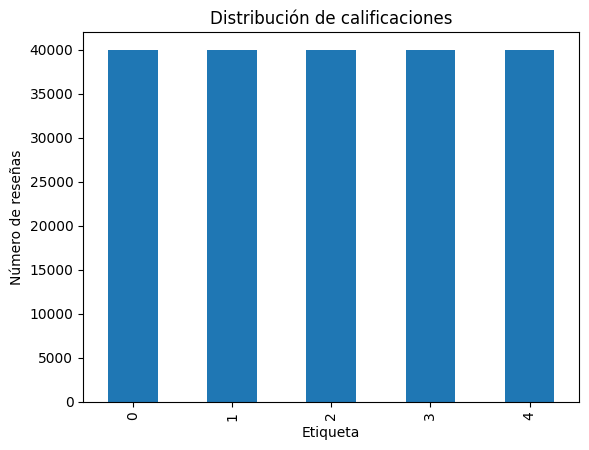

In [11]:
df_train["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de calificaciones")
plt.xlabel("Etiqueta")
plt.ylabel("Número de reseñas")
plt.show()

In [12]:
df_train["longitud_palabras"] = df_train["text"].apply(
    lambda x: len(str(x).split())
)

df_train["longitud_palabras"].describe()

,longitud_palabras
count,200000.000000
mean,31.120780
std,24.817574
min,3.000000
25%,15.000000
50%,25.000000
75%,38.000000
max,566.000000


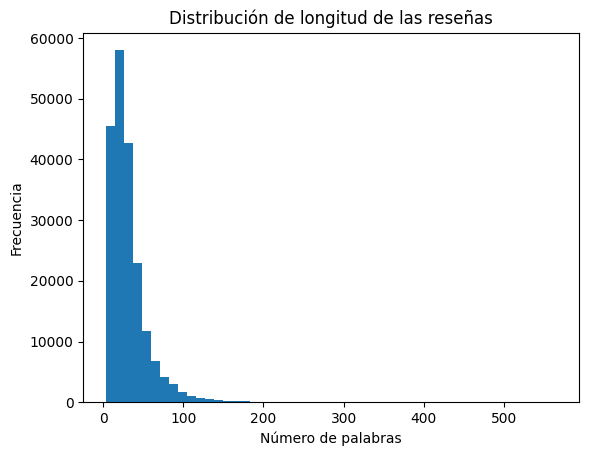

In [13]:
plt.hist(df_train["longitud_palabras"], bins=50)

plt.title("Distribución de longitud de las reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación del EDA

El conjunto de entrenamiento contiene 200.000 reseñas y presenta una
distribución aproximadamente balanceada entre las cinco categorías de
calificación. Cada etiqueta contiene alrededor de 40.000 ejemplos, por lo
que no se observa un problema relevante de desbalance de clases.

En relación con la longitud de las reseñas, se observa que la mayoría de
los textos son relativamente cortos. La longitud media es de aproximadamente
31 palabras y la mediana es de 25 palabras.

El 75 % de las reseñas contiene 38 palabras o menos, aunque existen algunos
casos considerablemente más extensos, alcanzando un máximo de 566 palabras.

La distribución presenta una asimetría positiva, con una concentración
importante de reseñas cortas y una cola hacia textos de mayor longitud.

Este comportamiento será tenido en cuenta durante la preparación del corpus,
ya que permitirá definir una longitud máxima adecuada para el entrenamiento
del modelo sin dedicar recursos excesivos a unos pocos textos atípicamente
largos.

In [14]:
for etiqueta in sorted(df_train["label"].unique()):
    ejemplo = df_train[df_train["label"] == etiqueta].iloc[0]

    print("=" * 80)
    print(f"Etiqueta: {etiqueta}")
    print(ejemplo["text"])
    print()

Etiqueta: 0
television Nevir

Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante

Etiqueta: 1
Regular

Los tornillos no ajustan bien, se caen. No lo volvería a comprar

Etiqueta: 2
buena funda para movil 5,5

cabe bien un móvil de 5,5 y cumple su función se hecha de menos un pequeño espacio para guardar tarjeta o efectivo seria muy útil

Etiqueta: 3
Calidad

Tiene buena pinta, veremos el resultado

Etiqueta: 4
Muy útil

Es muy práctico para cuando me voy de vacaciones, ya no me tengo que preocupar de si seguirán vivas las plantas cuando vuelva. El montaje es muy sencillo y se puede regular la salida de agua para que caiga una gota cada cierto tiempo. Lo recomiendo.



### Exploración cualitativa

Además del análisis estadístico, se revisan ejemplos de cada categoría de
calificación para identificar diferencias en el vocabulario, tono y contenido
de las reseñas.

Esta revisión será útil posteriormente para evaluar de forma cualitativa
si los textos generados mantienen características similares a las reseñas
reales del corpus.

### Interpretación cualitativa

La revisión de ejemplos confirma que las etiquetas representan distintos
niveles de valoración.

Las etiquetas más bajas contienen expresiones claramente negativas,
relacionadas con fallos, inconformidad o rechazo del producto. Las etiquetas
intermedias presentan opiniones más equilibradas, mientras que las etiquetas
más altas utilizan un lenguaje predominantemente positivo.

Esta relación entre la calificación y el contenido de la reseña permite
plantear una estrategia de generación condicionada, incorporando la
calificación como parte del contexto de entrada al modelo.

## 5. Preparación del corpus

Para el entrenamiento del modelo generativo se construirá una representación
textual que combine la calificación de la reseña con su contenido.

De esta manera, el modelo podrá aprender no solamente a generar texto con
la estructura de una reseña, sino también a relacionar diferentes estilos
de lenguaje con distintos niveles de calificación.

In [15]:
def construir_texto_generativo(ejemplo):
    estrellas = int(ejemplo["label"]) + 1

    return {
        "texto_generativo":
        f"Calificación: {estrellas} estrellas\n"
        f"Reseña: {ejemplo['text']}"
    }

dataset_generativo = raw.map(construir_texto_generativo)

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [16]:
for i in range(5):
    print("=" * 80)
    print(dataset_generativo["train"][i]["texto_generativo"])
    print()

Calificación: 1 estrellas
Reseña: television Nevir

Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante

Calificación: 1 estrellas
Reseña: Dinero tirado a la basura con esta compra

Horrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, ni un informático, después de una hora fue capaz de instalarlo

Calificación: 1 estrellas
Reseña: solo llega una unidad cuando te obligan a comprar dos

Te obligan a comprar dos unidades y te llega solo una y no hay forma de reclamar, una autentica estafa, no compreis!!

Calificación: 1 estrellas
Reseña: PRODUCTO NO RECIBIDO.

No entro en descalificar al vendedor, solo puedo decir que tras dos meses de espera.... sigo sin el producto y tuve que contactar con Amazon para reclamar su reembolso. Amazon un 10 . Se hace cargo del problema, pero yo e desembolsado mi dinero y en dos meses me lo devuelven Perdida de tiempo TOTAL. Sin palabras. Y Ustedes deciden

Calificación: 1 estrellas
Reseña: 

In [17]:
muestras_por_clase = 4000

partes = []

for etiqueta in sorted(df_train["label"].unique()):
    parte = df_train[df_train["label"] == etiqueta].sample(
        n=muestras_por_clase,
        random_state=SEED
    )
    partes.append(parte)

df_muestra = pd.concat(partes)

df_muestra = df_muestra.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Número total de reseñas:", len(df_muestra))
print()
print(df_muestra["label"].value_counts().sort_index())

Número total de reseñas: 20000

label
0    4000
1    4000
2    4000
3    4000
4    4000
Name: count, dtype: int64


## 6. Selección del modelo generativo

Para la tarea de generación se utilizará un modelo autoregresivo basado en GPT-2.

Los modelos autoregresivos generan texto prediciendo el siguiente token a partir
de los tokens anteriores. Esta característica permite estudiar directamente
diferentes estrategias de decodificación como Greedy, Sampling, Temperature,
Top-k y Top-p.

Se empleará un modelo preentrenado en español y posteriormente se realizará
fine-tuning con una muestra balanceada del dataset Amazon Reviews Multi.

In [18]:
MODEL_NAME = "datificate/gpt2-small-spanish"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model = model.to(device)

print("Modelo cargado:", MODEL_NAME)
print("Dispositivo:", device)

config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/850k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/508k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Modelo cargado: datificate/gpt2-small-spanish
Dispositivo: cuda


In [19]:
print("Tamaño del vocabulario:", len(tokenizer))
print("Token EOS:", tokenizer.eos_token)
print("Token PAD:", tokenizer.pad_token)

Tamaño del vocabulario: 50257
Token EOS: <|endoftext|>
Token PAD: <|endoftext|>


In [20]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

print("PAD token:", tokenizer.pad_token)
print("PAD token id:", tokenizer.pad_token_id)

PAD token: <|endoftext|>
PAD token id: 0


## 7. Generación base antes del fine-tuning

Antes de entrenar el modelo con las reseñas de Amazon, se realiza una generación
inicial para observar el comportamiento del modelo preentrenado.

Este resultado servirá posteriormente como referencia para analizar el efecto
del fine-tuning sobre el dominio de reseñas de productos.

In [21]:
prompt = "Calificación: 5 estrellas\nReseña:"

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id
    )

texto_generado = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(texto_generado)

Calificación: 5 estrellas
Reseña: 1.5
Reseña: 0
Reseña: 0.0

Reseña: 0.1

Reseña: 0.1

Reseña: 0.1

Reseña:


### Interpretación de la generación base

Antes del fine-tuning, el modelo no genera una reseña coherente a partir
del formato propuesto.

Aunque reconoce parcialmente la estructura textual del prompt, la salida
incluye valores numéricos y repeticiones de la palabra "Reseña", en lugar
de producir una opinión natural sobre un producto.

Este comportamiento era esperable, ya que el modelo preentrenado no ha sido
ajustado específicamente al dominio de reseñas de Amazon ni al formato
"Calificación + Reseña".

Esta generación servirá como línea base para comparar el efecto del
fine-tuning sobre el comportamiento del modelo.

## 8. Preparación de los datos para fine-tuning

In [22]:
def preparar_texto(row):
    estrellas = int(row["label"]) + 1

    return (
        f"Calificación: {estrellas} estrellas\n"
        f"Reseña: {row['text']}{tokenizer.eos_token}"
    )

df_muestra["texto_entrenamiento"] = df_muestra.apply(
    preparar_texto,
    axis=1
)

df_muestra[
    ["label", "texto_entrenamiento"]
].head()

,label,texto_entrenamiento
0,2,Calificación: 3 estrellas\nReseña: Parece prot...
1,0,Calificación: 1 estrellas\nReseña: NO TRAE BAL...
2,2,Calificación: 3 estrellas\nReseña: Su efecto\n...
3,0,Calificación: 1 estrellas\nReseña: No ha llega...
4,3,Calificación: 4 estrellas\nReseña: Todo bien\n...


In [23]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_muestra,
    test_size=0.1,
    random_state=SEED,
    stratify=df_muestra["label"]
)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))

print("\nDistribución entrenamiento:")
print(train_df["label"].value_counts().sort_index())

print("\nDistribución validación:")
print(val_df["label"].value_counts().sort_index())

Entrenamiento: 18000
Validación: 2000

Distribución entrenamiento:
label
0    3600
1    3600
2    3600
3    3600
4    3600
Name: count, dtype: int64

Distribución validación:
label
0    400
1    400
2    400
3    400
4    400
Name: count, dtype: int64


## 9. Tokenización del corpus

Las reseñas deben transformarse en secuencias de tokens antes de ser utilizadas
por el modelo.

Se utilizará una longitud máxima de 128 tokens. Esta decisión busca conservar
la mayor parte del contenido de las reseñas y, al mismo tiempo, limitar el
costo computacional del entrenamiento.

In [24]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["texto_entrenamiento"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_df[["texto_entrenamiento"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['texto_entrenamiento'],
    num_rows: 18000
})
Dataset({
    features: ['texto_entrenamiento'],
    num_rows: 2000
})


In [25]:
MAX_LENGTH = 128

def tokenizar(batch):
    return tokenizer(
        batch["texto_entrenamiento"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tokenized = train_dataset.map(
    tokenizar,
    batched=True,
    remove_columns=["texto_entrenamiento"]
)

val_tokenized = val_dataset.map(
    tokenizar,
    batched=True,
    remove_columns=["texto_entrenamiento"]
)

print(train_tokenized)
print(val_tokenized)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 18000
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2000
})


In [26]:
print("IDs de tokens:")
print(train_tokenized[0]["input_ids"][:30])

print("\nNúmero de tokens del ejemplo:")
print(len(train_tokenized[0]["input_ids"]))

print("\nTexto reconstruido:")
print(
    tokenizer.decode(
        train_tokenized[0]["input_ids"]
    )
)

IDs de tokens:
[10286, 2311, 26, 324, 5648, 199, 50, 2443, 906, 26, 1437, 16772, 265, 3150, 199, 199, 491, 24854, 306, 8809, 973, 287, 5639, 284, 11916, 265, 351, 2535, 34749, 265]

Número de tokens del ejemplo:
43

Texto reconstruido:
Calificación: 1 estrellas
Reseña: Lo enviaron a Inglaterra

El vendedor se confundió y envió el pedido a una dirección aleatoria a reino unido. El vendedor nunca se puso en contacto conmigo.<|endoftext|>


In [27]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator configurado para lenguaje causal.")

Data collator configurado para lenguaje causal.


### Interpretación de la tokenización

La tokenización transformó correctamente las reseñas en secuencias de
identificadores numéricos que pueden ser procesados por GPT-2.

El ejemplo inspeccionado contiene 43 tokens, por debajo del límite máximo
establecido de 128 tokens. Al decodificar nuevamente la secuencia se conserva
la estructura propuesta de calificación y reseña, incluyendo el token especial
de finalización `<|endoftext|>`.

El uso de una longitud máxima de 128 tokens permite cubrir ampliamente las
reseñas típicas observadas durante el EDA, mientras limita el costo
computacional asociado al entrenamiento.

Finalmente, el `DataCollatorForLanguageModeling` se configura con
`mlm=False`, ya que GPT-2 utiliza modelado de lenguaje causal: aprende a
predecir el siguiente token a partir de los tokens anteriores.

## 10. Fine-tuning del modelo

El modelo GPT-2 preentrenado será ajustado utilizando el subconjunto
balanceado de reseñas preparado anteriormente.

El objetivo del fine-tuning es adaptar el conocimiento lingüístico general
del modelo al dominio específico de las reseñas de productos y al formato
condicionado por calificación.

Para mantener un costo computacional razonable se realizará inicialmente
una época de entrenamiento. El desempeño se evaluará periódicamente sobre
el conjunto de validación mediante la pérdida de lenguaje causal.

In [28]:
import transformers

print("Versión de Transformers:", transformers.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de Transformers: 5.18.0
GPU disponible: True
GPU: Tesla T4


In [29]:
from transformers import TrainingArguments, Trainer

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./resultados_gpt2",

    num_train_epochs=1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=100,

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    seed=SEED
)

print("TrainingArguments configurados correctamente.")

TrainingArguments configurados correctamente.


In [30]:
model.config.use_cache = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator
)

print("Trainer configurado correctamente.")

Trainer configurado correctamente.


In [31]:
trainer.evaluate()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Step
No log,4.986540,0


{'eval_loss': 4.9865403175354}

In [32]:
import transformers

print("Versión de transformers:", transformers.__version__)

Versión de transformers: 5.18.0


## 11. Entrenamiento del modelo

In [33]:
resultado_entrenamiento = trainer.train()

Step,Training Loss
100,4.250429
200,3.666583
300,3.517376
400,3.375738
500,3.300471
600,3.274184
700,3.230298
800,3.242644
900,3.147101
1000,3.166578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
resultado_entrenamiento

TrainOutput(global_step=1125, training_loss=3.3910933159722223, metrics={'train_runtime': 406.8393, 'train_samples_per_second': 44.244, 'train_steps_per_second': 2.765, 'total_flos': 873217557504000.0, 'train_loss': 3.3910933159722223, 'epoch': 1.0})

In [35]:
evaluacion_final = trainer.evaluate()

evaluacion_final

Training Loss,Validation Loss,Step
3.178298,3.019685,1125


{'eval_loss': 3.0196845531463623}

### Interpretación del Entrenamiento

El proceso de fine-tuning produjo una reducción clara de la función de pérdida.

Antes del entrenamiento, el modelo presentaba una `eval_loss` aproximada de 4.99.
Después de una época de fine-tuning, la pérdida de validación disminuyó hasta
aproximadamente 3.02.

Esta reducción indica que el modelo se adaptó mejor al dominio de reseñas de
productos y al formato condicionado por calificación utilizado durante el
entrenamiento.

Además, la pérdida de entrenamiento mostró una tendencia descendente durante
la época, lo cual sugiere que el modelo fue aprendiendo progresivamente los
patrones lingüísticos presentes en el corpus.

Aunque una sola época no garantiza un ajuste óptimo, los resultados son
suficientes para continuar con el objetivo principal del experimento:
comparar diferentes estrategias de decodificación sobre un mismo modelo
fine-tuned.

In [38]:
model.config.use_cache = True
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [39]:
def generar_resena(
    estrellas,
    max_new_tokens=60,
    do_sample=False,
    temperature=1.0,
    top_k=0,
    top_p=1.0
):
    prompt = f"Calificación: {estrellas} estrellas\nReseña:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    parametros = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "do_sample": do_sample
    }

    if do_sample:
        parametros["temperature"] = temperature
        parametros["top_k"] = top_k
        parametros["top_p"] = top_p

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **parametros
        )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

In [40]:
for estrellas in [1, 3, 5]:
    print("=" * 80)
    print(f"GREEDY - {estrellas} estrellas")
    print(
        generar_resena(
            estrellas=estrellas,
            do_sample=False
        )
    )
    print()

GREEDY - 1 estrellas
Calificación: 1 estrellas
Reseña: No me ha llegado

No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado. No me ha llegado

GREEDY - 3 estrellas
Calificación: 3 estrellas
Reseña: No es lo que esperaba

No es lo que esperaba, pero es lo que esperaba. No es lo que esperaba. No es lo que esperaba. No es lo que esperaba. No es lo que esperaba. No es lo que esperaba. No es lo que esperaba. No es lo que esperaba

GREEDY - 5 estrellas
Calificación: 5 estrellas
Reseña: Muy buena compra

Muy buena compra. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy buena calidad precio. Muy



### Interpretación de Greedy Decoding

Los resultados muestran que el modelo fine-tuned aprendió a relacionar la
calificación con el tono general de la reseña.

Para una calificación de 1 estrella se genera contenido predominantemente
negativo, mientras que para 5 estrellas aparecen expresiones claramente
positivas. La salida de 3 estrellas presenta un tono más intermedio.

Sin embargo, las tres generaciones muestran un problema importante de
repetición. El modelo tiende a reutilizar continuamente las mismas frases.

Este comportamiento es consistente con Greedy Decoding, ya que esta estrategia
selecciona en cada paso el token con mayor probabilidad y no introduce
aleatoriedad durante la generación.

Por esta razón, aunque Greedy puede producir secuencias deterministas y
relativamente coherentes con la calificación solicitada, puede perder
diversidad y caer en ciclos repetitivos.

## 13. Generación mediante Sampling

A diferencia de Greedy Decoding, el muestreo selecciona el siguiente token
a partir de la distribución de probabilidades producida por el modelo.

Esto introduce variabilidad en la generación y puede aumentar la diversidad
del texto, aunque también puede producir resultados menos predecibles.

In [41]:
torch.manual_seed(SEED)

for estrellas in [1, 3, 5]:
    print("=" * 80)
    print(f"SAMPLING - {estrellas} estrellas")

    print(
        generar_resena(
            estrellas=estrellas,
            do_sample=True,
            temperature=1.0,
            top_k=0,
            top_p=1.0
        )
    )

    print()

SAMPLING - 1 estrellas
Calificación: 1 estrellas
Reseña: Poca forma

Son aparatos de Artículo para poco más de lo esperado. Encima tenía una especie de varilla precisamente que iba a ser un mejor embalaje. La forma sin indicar es aunque aceptable pero la calidad pobre. Corre la opción de modelar bien o bien pero todo hubiera biológica artificial.

SAMPLING - 3 estrellas
Calificación: 3 estrellas
Reseña: Muy mala versión de Amazon!!!

Muy mala manera de hablar. El sistema automático y es bonito. El precio por absoluto cancelado. La parte baja cual estoy por bajar la web solo es para unos libros de viaje de la costa, quedando sólo partes de él, lo cual en mi indica intentado

SAMPLING - 5 estrellas
Calificación: 5 estrellas
Reseña: Perceptibles

Me gustó q esta muy cómoda es queallisima , volviendo a comprar mi cambiar de opinador a la ida las he pedido y no hay posibilidad de devolver el dinero. La dispensación también es muy cómoda. salteñeria super bonita. Le encanta. Bastante:



### Interpretación del Sampling

El uso de muestreo produce textos claramente más diversos que Greedy Decoding.

Las generaciones presentan menos repetición y una mayor variedad léxica.
Sin embargo, también aparecen frases menos naturales y algunas combinaciones
semánticas poco coherentes.

Este comportamiento refleja el compromiso existente entre diversidad y
coherencia en los modelos generativos: al permitir que el modelo seleccione
tokens distintos al más probable, se amplía el espacio de generación, pero
también aumenta la posibilidad de producir secuencias menos consistentes.

Además, aunque el tono general conserva cierta relación con la calificación,
el control es menos estable que con Greedy Decoding.

## 14. Efecto de la temperatura

La temperatura modifica la distribución de probabilidades utilizada durante
el muestreo.

Valores bajos de temperatura hacen que la distribución sea más concentrada
y favorecen tokens de alta probabilidad, produciendo textos más conservadores.

Valores altos hacen que la distribución sea más uniforme, aumentando la
diversidad, pero también el riesgo de generar texto menos coherente.

En este experimento se compararán diferentes valores de temperatura
manteniendo constantes los demás parámetros.

In [42]:
temperaturas = [0.5, 0.8, 1.0, 1.2]

for temp in temperaturas:
    torch.manual_seed(SEED)

    print("=" * 80)
    print(f"TEMPERATURE = {temp}")

    texto = generar_resena(
        estrellas=5,
        do_sample=True,
        temperature=temp,
        top_k=0,
        top_p=1.0
    )

    print(texto)
    print()

TEMPERATURE = 0.5
Calificación: 5 estrellas
Reseña: Buen producto

Buena calidad y precio. El producto es muy bueno, pero no me ha gustado mucho. El color es muy bonito, pero no es tan bonito como en la foto. El color es muy bonito, pero no es tan bonito como en la foto. El precio es muy bueno

TEMPERATURE = 0.8
Calificación: 5 estrellas
Reseña: Buen producto

Buena calidad y asequible para lo que seria. Muy práctico. Muy buen producto. Rapidez. El producto llegó en tiempo. Lo más recomendable es el precio. Muy satisfecho aunque la calidad no lo recomiendo. Se puede equiparse con el producto. Muy bien realizado. Lle

TEMPERATURE = 1.0
Calificación: 5 estrellas
Reseña: Buen producto, calidad de imagen y sonido

Me ha gustado el precio. Muy buen producto, salvo el flojo que trae. Correcta y baja calidad de sonido. El parecía esilas aceptable pero la calidad pobre. Correcta embalativa bien, correcto embalaje. reproducir aunque al

TEMPERATURE = 1.2
Calificación: 5 estrellas
Reseña: Buen p

### Interpretación del experimento de temperatura

Los resultados muestran que la temperatura influye directamente en el equilibrio
entre coherencia y diversidad.

Con una temperatura baja (`0.5`), el modelo genera textos más conservadores y
predecibles. La coherencia general es mayor, aunque también aparece repetición
de algunas expresiones.

Con una temperatura intermedia (`0.8`), el texto mantiene una buena relación
con la calificación solicitada y presenta mayor diversidad léxica, sin perder
demasiada coherencia.

Con `1.0`, la generación se vuelve más variada, pero aparecen contradicciones
y estructuras menos naturales.

Finalmente, con una temperatura alta (`1.2`), el modelo introduce mayor
aleatoriedad y el texto pierde estabilidad, produciendo frases menos coherentes.

En este experimento, los valores intermedios de temperatura ofrecen un mejor
compromiso entre diversidad y coherencia.

## 15. Comparación de Top-k y Top-p

Top-k limita la selección del siguiente token a los `k` tokens con mayor
probabilidad.

Top-p, también conocido como Nucleus Sampling, selecciona dinámicamente el
conjunto mínimo de tokens cuya probabilidad acumulada alcanza un umbral `p`.

Ambas estrategias buscan reducir la generación de tokens poco probables,
manteniendo cierto grado de diversidad.

In [43]:
torch.manual_seed(SEED)

print("=" * 80)
print("TOP-K")

texto_top_k = generar_resena(
    estrellas=5,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=1.0
)

print(texto_top_k)

TOP-K
Calificación: 5 estrellas
Reseña: Buen producto

Buena calidad y la única pega es que tiene muy poco peso. Por lo demás una buena compra. El producto esta bien. El servicio es excelente y la entrega sin ningún problema aunque la calidad no lo recomiendo. Se puede decir que es el producto más caro de España y de


In [44]:
torch.manual_seed(SEED)

print("=" * 80)
print("TOP-P")

texto_top_p = generar_resena(
    estrellas=5,
    do_sample=True,
    temperature=0.8,
    top_k=0,
    top_p=0.90
)

print(texto_top_p)

TOP-P
Calificación: 5 estrellas
Reseña: Buen producto

Buena calidad y la única pega es que tiene muy poco peso. Por lo demás una buena compra. El producto esta bien. El mejor precio es que trae la bicicleta pero es muy pequeño y no lo recomiendo. Se puede montar en cualquier coche. Es lo que esperaba. Es


In [45]:
torch.manual_seed(SEED)

print("=" * 80)
print("TOP-K + TOP-P")

texto_combinado = generar_resena(
    estrellas=5,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=0.90
)

print(texto_combinado)

TOP-K + TOP-P
Calificación: 5 estrellas
Reseña: Buen producto

Buena calidad y la única pega es que tiene muy poco peso. Por lo demás bien. Es muy bonito, pero es muy pesado. Además es muy bonito y fácil de usar. El producto está muy bien. Pero la batería es bastante pequeña y es demasiado caro. Para llevar algo


### Interpretación de Top-k y Top-p

Las estrategias Top-k y Top-p permiten introducir diversidad sin utilizar
todo el vocabulario disponible en cada paso de generación.

Con Top-k (`k=50`), el modelo restringe la selección a los 50 tokens más
probables. Esto produce una generación relativamente estable y coherente,
reduciendo la aparición de palabras poco probables.

Top-p (`p=0.90`) utiliza un conjunto dinámico de candidatos cuya probabilidad
acumulada alcanza el 90 %. Este mecanismo mantiene diversidad y adapta el
número de tokens candidatos a la distribución producida por el modelo.

La combinación de Top-k y Top-p también genera textos razonablemente naturales,
aunque pueden aparecer pequeñas inconsistencias semánticas.

En comparación con el muestreo sin restricciones, estas estrategias ofrecen
un mejor equilibrio entre diversidad y coherencia.

## 16. Evaluación cuantitativa de las estrategias de decodificación

Además de inspeccionar visualmente los textos generados, se utilizarán métricas
simples para comparar la diversidad y repetición de las distintas estrategias.

Se calcularán:

- **Longitud:** número total de palabras generadas.
- **Distinct-1:** proporción de palabras diferentes respecto al total.
- **Distinct-2:** proporción de bigramas diferentes respecto al total.
- **Repetición:** proporción aproximada de palabras repetidas.

Valores altos de Distinct-1 y Distinct-2 indican mayor diversidad léxica,
mientras que una repetición elevada puede indicar generación redundante.

In [47]:
def calcular_metricas(texto):
    # Quitamos el prompt para analizar principalmente la reseña generada
    if "Reseña:" in texto:
        texto = texto.split("Reseña:", 1)[1]

    palabras = texto.lower().split()

    if len(palabras) == 0:
        return {
            "longitud": 0,
            "distinct_1": 0,
            "distinct_2": 0,
            "repeticion": 0
        }

    # Distinct-1
    distinct_1 = len(set(palabras)) / len(palabras)

    # Bigramas
    bigramas = list(zip(palabras[:-1], palabras[1:]))

    if len(bigramas) > 0:
        distinct_2 = len(set(bigramas)) / len(bigramas)
    else:
        distinct_2 = 0

    # Proporción de repetición
    repeticion = 1 - distinct_1

    return {
        "longitud": len(palabras),
        "distinct_1": distinct_1,
        "distinct_2": distinct_2,
        "repeticion": repeticion
    }

In [48]:
estrategias = {
    "Greedy": {
        "do_sample": False
    },

    "Sampling": {
        "do_sample": True,
        "temperature": 1.0,
        "top_k": 0,
        "top_p": 1.0
    },

    "Temperature 0.8": {
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 0,
        "top_p": 1.0
    },

    "Top-k": {
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 50,
        "top_p": 1.0
    },

    "Top-p": {
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 0,
        "top_p": 0.90
    },

    "Top-k + Top-p": {
        "do_sample": True,
        "temperature": 0.8,
        "top_k": 50,
        "top_p": 0.90
    }
}

In [49]:
resultados = []

for nombre, parametros in estrategias.items():

    for i in range(10):

        torch.manual_seed(SEED + i)

        texto = generar_resena(
            estrellas=5,
            **parametros
        )

        metricas = calcular_metricas(texto)

        resultados.append({
            "estrategia": nombre,
            "texto": texto,
            **metricas
        })

df_resultados = pd.DataFrame(resultados)

df_resultados.head()

,estrategia,texto,longitud,distinct_1,distinct_2,repeticion
0,Greedy,Calificación: 5 estrellas\nReseña: Muy buena c...,47,0.12766,0.173913,0.87234
1,Greedy,Calificación: 5 estrellas\nReseña: Muy buena c...,47,0.12766,0.173913,0.87234
2,Greedy,Calificación: 5 estrellas\nReseña: Muy buena c...,47,0.12766,0.173913,0.87234
3,Greedy,Calificación: 5 estrellas\nReseña: Muy buena c...,47,0.12766,0.173913,0.87234
4,Greedy,Calificación: 5 estrellas\nReseña: Muy buena c...,47,0.12766,0.173913,0.87234


In [50]:
resumen_metricas = (
    df_resultados
    .groupby("estrategia")[
        ["longitud", "distinct_1", "distinct_2", "repeticion"]
    ]
    .mean()
    .round(3)
)

resumen_metricas

,longitud,distinct_1,distinct_2,repeticion
estrategia,,,,
Greedy,47.0,0.128,0.174,0.872
Sampling,46.1,0.826,0.993,0.174
Temperature 0.8,48.2,0.782,0.979,0.218
Top-k,48.2,0.703,0.929,0.297
Top-k + Top-p,46.3,0.686,0.912,0.314
Top-p,48.2,0.708,0.949,0.292


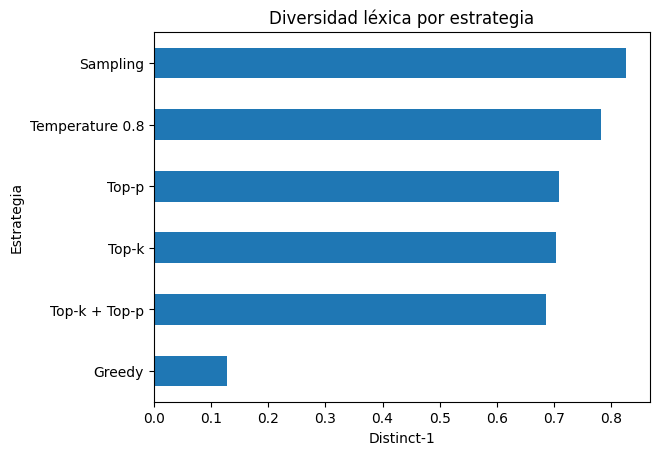

In [51]:
resumen_metricas["distinct_1"].sort_values().plot(
    kind="barh"
)

plt.title("Diversidad léxica por estrategia")
plt.xlabel("Distinct-1")
plt.ylabel("Estrategia")
plt.show()

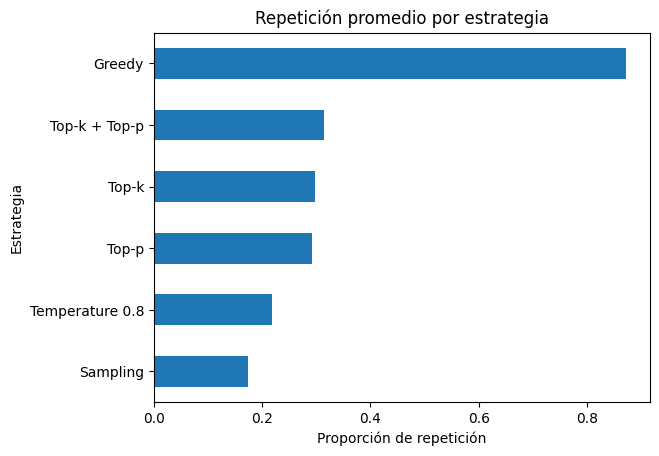

In [52]:
resumen_metricas["repeticion"].sort_values().plot(
    kind="barh"
)

plt.title("Repetición promedio por estrategia")
plt.xlabel("Proporción de repetición")
plt.ylabel("Estrategia")
plt.show()

### Interpretación cuantitativa

Los resultados confirman las diferencias observadas cualitativamente entre
las estrategias de decodificación.

**Greedy Decoding** presenta la menor diversidad léxica y la mayor repetición.
Su `Distinct-1` es de aproximadamente 0.128 y la proporción de repetición
alcanza 0.872. Esto demuestra que la estrategia determinista tiende a reutilizar
las mismas palabras y secuencias.

**Sampling** obtiene los mayores valores de diversidad (`Distinct-1 = 0.826`
y `Distinct-2 = 0.993`) y la menor repetición (`0.174`). Sin embargo, en la
inspección cualitativa se observaron también frases menos estables y algunas
inconsistencias semánticas.

La configuración con **Temperature = 0.8** mantiene una diversidad elevada
(`Distinct-1 = 0.782`, `Distinct-2 = 0.979`) y una repetición relativamente
baja (`0.218`), conservando además una mayor estabilidad que el muestreo puro.

Las estrategias **Top-k** y **Top-p** restringen el espacio de candidatos,
reduciendo ligeramente la diversidad pero mejorando el control de la
generación. La combinación Top-k + Top-p resulta más restrictiva y presenta
una repetición mayor que las configuraciones individuales.

En conjunto, los resultados sugieren que una temperatura intermedia,
especialmente `0.8`, ofrece un buen equilibrio entre diversidad y estabilidad.

## 17. Evaluación de coherencia semántica

Las métricas Distinct-1 y Distinct-2 permiten estudiar la diversidad léxica,
pero no indican si las diferentes partes de un texto mantienen una relación
semántica entre sí.

Por esta razón, se incorpora una medida aproximada de coherencia semántica
basada en embeddings de oraciones.

Cada reseña generada se divide en dos segmentos y se calcula la similitud
coseno entre sus representaciones vectoriales.

Un valor cercano a 1 indica una mayor similitud semántica entre ambas partes,
mientras que valores menores sugieren una menor relación temática.

Esta métrica debe interpretarse como un indicador complementario y no como
una medida absoluta de calidad del texto.

In [53]:
!pip install -q sentence-transformers

In [54]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

modelo_semantico = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Modelo semántico cargado correctamente.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo semántico cargado correctamente.


In [55]:
def calcular_coherencia(texto):

    # Eliminamos el prompt
    if "Reseña:" in texto:
        texto = texto.split("Reseña:", 1)[1].strip()

    palabras = texto.split()

    # Si el texto es demasiado corto, no calculamos la métrica
    if len(palabras) < 6:
        return np.nan

    mitad = len(palabras) // 2

    segmento_1 = " ".join(palabras[:mitad])
    segmento_2 = " ".join(palabras[mitad:])

    embeddings = modelo_semantico.encode(
        [segmento_1, segmento_2]
    )

    similitud = cosine_similarity(
        [embeddings[0]],
        [embeddings[1]]
    )[0][0]

    return float(similitud)

In [56]:
df_resultados["coherencia"] = df_resultados["texto"].apply(
    calcular_coherencia
)

df_resultados[
    ["estrategia", "longitud", "distinct_1",
     "distinct_2", "repeticion", "coherencia"]
].head()

,estrategia,longitud,distinct_1,distinct_2,repeticion,coherencia
0,Greedy,47,0.12766,0.173913,0.87234,0.966178
1,Greedy,47,0.12766,0.173913,0.87234,0.966178
2,Greedy,47,0.12766,0.173913,0.87234,0.966178
3,Greedy,47,0.12766,0.173913,0.87234,0.966178
4,Greedy,47,0.12766,0.173913,0.87234,0.966178


In [57]:
resumen_final = (
    df_resultados
    .groupby("estrategia")[
        [
            "longitud",
            "distinct_1",
            "distinct_2",
            "repeticion",
            "coherencia"
        ]
    ]
    .mean()
    .round(3)
)

resumen_final

,longitud,distinct_1,distinct_2,repeticion,coherencia
estrategia,,,,,
Greedy,47.0,0.128,0.174,0.872,0.966
Sampling,46.1,0.826,0.993,0.174,0.420
Temperature 0.8,48.2,0.782,0.979,0.218,0.467
Top-k,48.2,0.703,0.929,0.297,0.449
Top-k + Top-p,46.3,0.686,0.912,0.314,0.585
Top-p,48.2,0.708,0.949,0.292,0.453


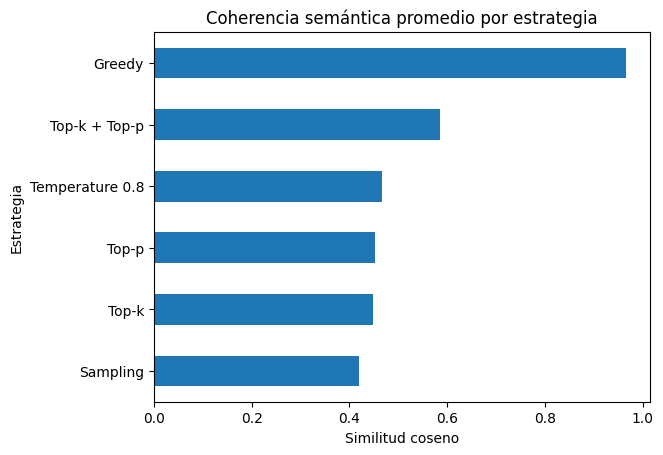

In [58]:
resumen_final["coherencia"].sort_values().plot(
    kind="barh"
)

plt.title("Coherencia semántica promedio por estrategia")
plt.xlabel("Similitud coseno")
plt.ylabel("Estrategia")
plt.show()

In [59]:
resumen_final

,longitud,distinct_1,distinct_2,repeticion,coherencia
estrategia,,,,,
Greedy,47.0,0.128,0.174,0.872,0.966
Sampling,46.1,0.826,0.993,0.174,0.420
Temperature 0.8,48.2,0.782,0.979,0.218,0.467
Top-k,48.2,0.703,0.929,0.297,0.449
Top-k + Top-p,46.3,0.686,0.912,0.314,0.585
Top-p,48.2,0.708,0.949,0.292,0.453


### Interpretación final de métricas

La comparación cuantitativa evidencia un compromiso claro entre diversidad,
repetición y coherencia semántica.

Greedy Decoding alcanza la mayor coherencia semántica (`0.966`), pero presenta
una diversidad muy baja y una repetición extremadamente alta (`0.872`).
Esto confirma que su aparente coherencia está asociada, en buena medida, a la
reutilización continua de expresiones similares.

Sampling ofrece la mayor diversidad léxica y la menor repetición, pero presenta
la coherencia semántica más baja (`0.420`). Por tanto, maximizar la diversidad
no necesariamente produce los textos más consistentes.

La configuración con `Temperature = 0.8` mantiene una diversidad elevada,
una repetición baja y una coherencia superior al muestreo puro, mostrando un
buen compromiso entre exploración y estabilidad.

Top-k + Top-p obtiene la mayor coherencia entre las estrategias de muestreo
(`0.585`), aunque con una reducción moderada en diversidad. Esto sugiere que
restringir el espacio de candidatos puede favorecer una generación más
controlada.

En conjunto, no existe una estrategia óptima para todas las métricas. La
elección depende del objetivo de generación: Greedy favorece estabilidad,
Sampling maximiza diversidad y configuraciones intermedias como Temperature
0.8 o Top-k + Top-p ofrecen un mejor equilibrio.

## 18. Limitaciones y trabajo futuro

Este experimento presenta algunas limitaciones.

En primer lugar, el fine-tuning se realizó durante una sola época y sobre una
muestra balanceada de 20.000 reseñas, por lo que un entrenamiento más extenso
podría mejorar la calidad de las generaciones.

En segundo lugar, la coherencia semántica se estimó mediante la similitud entre
dos segmentos del texto. Esta medida permite realizar una comparación
aproximada, pero no captura por completo aspectos como fluidez gramatical,
consistencia lógica o adecuación del tono.

También se evaluaron principalmente reseñas de 5 estrellas para comparar las
estrategias de decodificación bajo condiciones controladas.

Como trabajo futuro sería interesante:

- ampliar el entrenamiento;
- evaluar todas las categorías de calificación;
- utilizar métricas adicionales de fluidez y calidad;
- incorporar evaluación humana;
- comparar con modelos generativos más recientes;
- estudiar métodos automáticos de control de sentimiento.

## 19. Conclusiones

El proyecto permitió estudiar el efecto de diferentes estrategias de
decodificación sobre un modelo GPT-2 ajustado al dominio de reseñas de
productos en español.

El fine-tuning redujo la pérdida de validación de aproximadamente 4.99 a 3.02,
lo que indica una adaptación del modelo al corpus Amazon Reviews Multi.

Greedy Decoding generó textos relacionados con la calificación solicitada, pero
presentó un comportamiento altamente repetitivo.

El muestreo puro incrementó considerablemente la diversidad, aunque produjo
textos menos estables y con menor coherencia semántica.

Los experimentos con temperatura mostraron que los valores intermedios,
especialmente `0.8`, proporcionan un buen equilibrio entre diversidad y
control.

Top-k y Top-p permitieron restringir el espacio de generación y producir textos
más controlados que el muestreo puro. La combinación de ambas estrategias
alcanzó la mayor coherencia semántica entre los métodos de muestreo evaluados.

Los resultados muestran que no existe una única estrategia de decodificación
superior en todos los aspectos. Existe un compromiso entre coherencia,
diversidad y repetición, por lo que la configuración debe seleccionarse según
el objetivo específico de generación.

In [61]:
resumen_final.to_csv(
    "resumen_metricas.csv",
    index=True
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [62]:
from google.colab import files

files.download("resumen_metricas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>